<a href="https://colab.research.google.com/github/joshuajhchoi/ai2learn/blob/master/wgan_gp_with_MNIST_practice.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

## 복습

* 이 tutorial은 자동차 세트로 연습해본 GAN을 좀 더 가벼운 세트로 연습해보자는 뜻으로 만들었습니다. (Acknowledgement: 텐서플로우의 공식페이지의 예제와 위엠차크로운의 튜토리얼을 합하여 제작되었습니다)

* 자동차 이미지의 사이즈가 커서 너무 연습에 시간이 걸리므로 복습을 MNIST DB로 똑 같은 연습을 해보겠습니다

* WGAN Model에서 WGAN-GP모델로 바꾸어서 해봅니다

### 텐서플로와 다른 라이브러리 불러오기

*우선 텐서 플로우를 설치합니다

In [ ]:
!pip install tensorflow-gpu==2.0.0-rc1

     |████████████████████████████████| 380.5MB 41kB/s 
     |████████████████████████████████| 501kB 51.5MB/s 
     |████████████████████████████████| 4.3MB 45.5MB/s 
     |████████████████████████████████| 51kB 8.1MB/s 


In [ ]:
import tensorflow as tf

In [ ]:
tf.__version__

'2.0.0-rc1'

In [ ]:
# GIF를 만들기위해 설치합니다.
!pip install imageio

In [ ]:
import glob
import imageio
import matplotlib.pyplot as plt
import matplotlib.image as mpimg
import numpy as np
import os
import PIL
from PIL import Image
from tensorflow.keras import layers
import time
import random
from tensorflow import keras
%load_ext tensorboard
from IPython import display
from tensorflow.keras.initializers import RandomNormal

%matplotlib inline

### 데이터셋 로딩 및 준비
Generator와 critic를 훈련하기위해 MNIST 데이터셋을 사용할것입니다. Generator는 수기 숫자 데이터를 닮은 숫자들을 생성할 것입니다.

In [ ]:
(train_images, train_labels), (_, _) = tf.keras.datasets.mnist.load_data()

11493376/11490434 [==============================] - 0s 0us/step


In [ ]:
train_images = train_images.reshape(train_images.shape[0], 28, 28, 1).astype('float32')
train_images = (train_images - 127.5) / 127.5 # 이미지를 [-1, 1]로 정규화합니다.

In [ ]:
BUFFER_SIZE = 60000
BATCH_SIZE = 256
DIMS =(28,28,1)

In [ ]:
# 데이터 배치를 만들고 섞습니다.
train_dataset = tf.data.Dataset.from_tensor_slices(train_images).shuffle(BUFFER_SIZE).batch(BATCH_SIZE)

## 모델 만들기
Generator와 critic는 [케라스 Sequential API](https://www.tensorflow.org/guide/keras#sequential_model)를 이용해 정의됩니다.

### Generator

Generator는 기본적으로 wgan이나 wgan-GP나 마찬가지로 합니다

In [ ]:
def make_generator_model():
    model = tf.keras.Sequential()
    model.add(layers.Dense(7*7*256, use_bias=False, input_shape=(100,)))
    model.add(layers.BatchNormalization())
    model.add(layers.ReLU())

    model.add(layers.Reshape((7, 7, 256)))
    assert model.output_shape == (None, 7, 7, 256)

    model.add(layers.Conv2DTranspose(128, (5, 5), strides=(1, 1), padding='same', use_bias=False))
    assert model.output_shape == (None, 7, 7, 128)
    model.add(layers.BatchNormalization())
    model.add(layers.ReLU())

    model.add(layers.Conv2DTranspose(64, (5, 5), strides=(2, 2), padding='same', use_bias=False))
    assert model.output_shape == (None, 14, 14, 64)
    model.add(layers.BatchNormalization())
    model.add(layers.ReLU())

    model.add(layers.Conv2DTranspose(1, (5, 5), strides=(2, 2), padding='same', use_bias=False, activation='tanh'))
    assert model.output_shape == (None, 28, 28, 1)

    return model



(아직 훈련이 되지않은) generator를 이용해 이미지를 생성해봅시다.

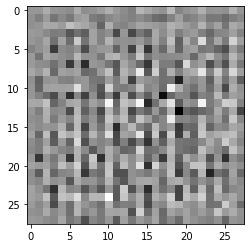

In [ ]:
generator = make_generator_model()
generator_model=make_generator_model()
noise = tf.random.normal([1, 100])
generated_image = generator(noise, training= False)

plt.imshow(generated_image[0, :, :, 0], cmap='gray')

### Critic


In [ ]:
def make_critic_model():
    model = tf.keras.Sequential()
    model.add(layers.Conv2D(64, (5, 5), strides=(2, 2), padding='same',
                                     input_shape=[28, 28, 1]))
    model.add(layers.ReLU())
    model.add(layers.Dropout(0.3))

    model.add(layers.Conv2D(128, (5, 5), strides=(2, 2), padding='same'))
    model.add(layers.ReLU())
    model.add(layers.Dropout(0.3))

    model.add(layers.Flatten())
    model.add(layers.Dense(1))

    return model

Generator와 마찬가지로 (아직까지 훈련이 되지 않은) critic를 사용하여, 생성된 이미지가 진짜인지 가짜인지 판별합니다. 모델은 진짜 이미지에는 양수의 값 (positive values)을, 가짜 이미지에는 음수의 값 (negative values)을 출력하도록 훈련되어집니다.

In [ ]:
critic = make_critic_model()
decision = critic(generated_image)
print (decision)

critic_model = make_critic_model()

tf.Tensor([[-0.00126742]], shape=(1, 1), dtype=float32)


## 손실함수와 옵티마이저 정의
두 모델의 손실함수와 옵티마이저를 정의합니다.

### Critic Loss Function

Wasserstein GAN은 1-Wasserstein distance를 사용하고 JS-Divergence를 사용하지 않고 모델 및 타겟 디스트리뷰숀을 측량합니다

In [ ]:
def critic_loss(real_output, fake_output):
    real_loss = - tf.reduce_mean(real_output)
    fake_loss = tf.reduce_mean(fake_output)
    return real_loss, fake_loss


Generator 손실함수
Generator의 손실함수는 critic를 얼마나 잘 속였는지에 대해 수치화를 합니다. 직관적으로 Generator가 원활히 수행되고 있다면, critic는 가짜 이미지를 진짜 (또는 1)로 분류를 할 것입니다. 여기서 우리는 생성된 이미지에 대한 critic의 결정을 1로 이루어진 행렬과 비교를 할 것입니다.

In [ ]:
def generator_loss(fake_output):
    fake_loss = - tf.reduce_mean(fake_output)
    return fake_loss

In [ ]:
class WGAN(keras.Model):
    def __init__(
        self,
        crtic,
        generator,
        latent_dim,
        critic_extra_steps=3,
        gp_weight=10.0,
    ):
        super(WGAN, self).__init__()
        self.critic = critic_model
        self.generator = generator_model
        self.latent_dim = latent_dim
        self.d_steps = critic_extra_steps
        self.gp_weight = gp_weight

    def compile(self, cri_optimizer, gen_optimizer, critic_loss_fn, generator_loss_fn):
        super(WGAN, self).compile()
        self.cri_optimizer = cri_optimizer
        self.gen_optimizer = gen_optimizer
        self.critic_loss_fn = critic_loss_fn
        self.generator_loss_fn = generator_loss_fn

    def gradient_penalty(self, batch_size, images, generated_images):
        # get the interplated image
        alpha = tf.random.normal([batch_size, 1, 1, 1], 0.0, 1.0)
        diff = generated_images - images
        interpolated = images + alpha * diff

        with tf.GradientTape() as gp_tape:
            gp_tape.watch(interpolated)
            # 1. Get the critic output for this interpolated image.
            pred = self.critic(interpolated, training=True)

        # 2. Calculate the gradients w.r.t to this interpolated image.
        grads = gp_tape.gradient(pred, [interpolated])[0]
        # 3. Calcuate the norm of the gradients
        norm = tf.sqrt(tf.reduce_sum(tf.square(grads), axis=[1, 2, 3]))
        gp = tf.reduce_mean((norm - 1.0) ** 2)
        return gp

    def train_step(self, images):
        if isinstance(images, tuple):
            images = images[0]

        # Get the batch size
        batch_size = tf.shape(images)[0]

        # For each batch, we are going to perform the
        # following steps as laid out in the original paper.
        # 1. Train the generator and get the generator loss
        # 2. Train the critic and get the critic loss
        # 3. Calculate the gradient penalty
        # 4. Multiply this gradient penalty with a constant weight factor
        # 5. Add gradient penalty to the critic loss
        # 6. Return generator and critic losses as a loss dictionary.

        # Train critic first. The original paper recommends training
        # the critic for `x` more steps (typically 5) as compared to
        # one step of the generator. Here we will train it for 3 extra steps
        # as compared to 5 to reduce the training time.
        for i in range(self.d_steps):
            # Get the latent vector
            random_latent_vectors = tf.random.normal(
                shape=(batch_size, self.latent_dim)
            )
            with tf.GradientTape() as tape:
                # Generate fake images from the latent vector
                generated_images = self.generator(random_latent_vectors, training=True)
                # Get the logits for the fake images
                fake_output = self.critic(generated_images, training=True)
                # Get the logits for real images
                real_output = self.critic(images, training=True)

                # Calculate critic loss using fake and real logits
                d_cost = self.critic_loss_fn(real_img=real_output, fake_img=fake_output)
                # Calculate the gradient penalty
                gp = self.gradient_penalty(batch_size, images, generated_images)
                # Add the gradient penalty to the original critic loss
                critic_loss = d_cost + gp * self.gp_weight

            # Get the gradients w.r.t the critic loss
            d_gradient = tape.gradient(critic_loss, self.critic.trainable_variables)
            # Update the weights of the critic using the critic optimizer
            self.cri_optimizer.apply_gradients(
                zip(d_gradient, self.critic.trainable_variables)
            )

        # Train the generator now.
        # Get the latent vector
        random_latent_vectors = tf.random.normal(shape=(batch_size, self.latent_dim))
        with tf.GradientTape() as tape:
            # Generate fake images using the generator
            generated_images = self.generator(random_latent_vectors, training=True)
            # Get the critic logits for fake images
            gen_img_logits = self.critic(generated_images, training=True)
            # Calculate the generator loss
            generator_loss = self.generator_loss_fn(gen_img_logits)

        # Get the gradients w.r.t the generator loss
        gen_gradient = tape.gradient(generator_loss, self.generator.trainable_variables)
        # Update the weights of the generator using the generator optimizer
        self.gen_optimizer.apply_gradients(
            zip(gen_gradient, self.generator.trainable_variables)
        )
        return {"critic_loss": critic_loss, "generator_loss": generator_loss}



In [ ]:
class GANMonitor(keras.callbacks.Callback):
    def __init__(self, num_img=6, latent_dim=128):
        self.num_img = num_img
        self.latent_dim = latent_dim

    def on_epoch_end(self, epoch, logs=None):
        random_latent_vectors = tf.random.normal(shape=(self.num_img, self.latent_dim))
        generated_images = self.model.generator(random_latent_vectors)
        generated_images = (generated_images * 127.5) + 127.5

        for i in range(self.num_img):
            img = generated_images[i].numpy()
            img = keras.preprocessing.image.array_to_img(img)
            img.save("generated_img_{i}_{epoch}.png".format(i=i, epoch=epoch))

In [ ]:
N_Z = 64

generator = [
    tf.keras.layers.Dense(units=7 * 7 * 64, activation="relu"),
    tf.keras.layers.Reshape(target_shape=(7, 7, 64)),
    tf.keras.layers.Conv2DTranspose(
        filters=64, kernel_size=3, strides=(2, 2), padding="SAME", activation="relu"
    ),
    tf.keras.layers.Conv2DTranspose(
        filters=32, kernel_size=3, strides=(2, 2), padding="SAME", activation="relu"
    ),
    tf.keras.layers.Conv2DTranspose(
        filters=1, kernel_size=3, strides=(1, 1), padding="SAME", activation="sigmoid"
    ),
]

discriminator = [
    tf.keras.layers.InputLayer(input_shape=DIMS),
    tf.keras.layers.Conv2D(
        filters=32, kernel_size=3, strides=(2, 2), activation="relu"
    ),
    tf.keras.layers.Conv2D(
        filters=64, kernel_size=3, strides=(2, 2), activation="relu"
    ),
    tf.keras.layers.Flatten(),
    tf.keras.layers.Dense(units=1, activation="sigmoid"),
]

In [ ]:
noise_dim = 100
EPOCHS = 100

# Optimizer for both the networks
# learning_rate=0.0002, beta_1=0.5 are recommened
gen_optimizer = keras.optimizers.Adam(
    learning_rate=0.0002, beta_1=0.5, beta_2=0.9
)
cri_optimizer = keras.optimizers.Adam(
    learning_rate=0.0002, beta_1=0.5, beta_2=0.9
)

# Define the loss functions to be used for discrimiator
# This should be (fake_loss - real_loss)
# We will add the gradient penalty later to this loss function
def critic_loss(real_img, fake_img):
    real_loss = tf.reduce_mean(real_img)
    fake_loss = tf.reduce_mean(fake_img)
    return fake_loss - real_loss


# Define the loss functions to be used for generator
def generator_loss(fake_img):
    return -tf.reduce_mean(fake_img)


# Epochs to train
epochs = 100

latent_dim=noise_dim

# Callbacks
cbk = GANMonitor(num_img=3, latent_dim=noise_dim)


# Get the wgan model
wgan = WGAN(critic, generator, latent_dim, critic_extra_steps=3, gp_weight=10.0)

# Compile the wgan model
wgan.compile(cri_optimizer=critic_optimizer,gen_optimizer=generator_optimizer,generator_loss_fn=generator_loss,critic_loss_fn=critic_loss)

# Start training
wgan.fit(train_images, batch_size=BATCH_SIZE, epochs=EPOCHS, callbacks=[cbk])




TypeError: ignored

In [ ]:
# 이미지 생성 및 저장

def generate_and_save_images(model, epoch, test_input):
  # `training`이 False로 맞춰진 것을 주목하세요.
  # 이렇게 하면 (배치정규화를 포함하여) 모든 층들이 추론 모드로 실행됩니다.
  predictions = model(test_input, training=False)

  fig = plt.figure(figsize=(4,4))

  for i in range(predictions.shape[0]):
      plt.subplot(4, 4, i+1)
      plt.imshow(predictions[i, :, :, 0] * 127.5 + 127.5, cmap='gray')
      plt.axis('off')

  plt.savefig('image_at_epoch_{:04d}.png'.format(epoch))
  plt.show()

## 다음 단계

다음에는 똑 같은 DB로 WGAN-LSGAN을 해봅니다